# **PHẦN 1: CÀI ĐẶT VÀ IMPORT THƯ VIỆN**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Thư viện cho Preprocessing & Split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

# Thư viện cho Oversampling
from imblearn.over_sampling import SMOTE, BorderlineSMOTE

# Các mô hình Machine Learning
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Thư viện đánh giá
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, make_scorer

import warnings
warnings.filterwarnings('ignore')

# **PHẦN 2: LOAD VÀ TIỀN XỬ LÝ DỮ LIỆU**

**2.1. Load dữ liệu**

In [2]:
import pandas as pd
import os

path = "../data/marketing_campaign.csv"

df = pd.read_csv(path, sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


**2.2. Xoá các cột không cần thiết**

In [3]:
drop_cols = ['ID', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Z_CostContact', 'Z_Revenue']
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

**2.3. Xử lý ngày tháng và tạo đặc trưng Tenure (Thâm niên)**

In [4]:
if 'Dt_Customer' in df.columns:
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')
    ref_date = pd.to_datetime('2025-11-20')
    df['Tenure_days'] = (ref_date - df['Dt_Customer']).dt.days
    df = df.drop(columns=['Dt_Customer'])

**2.4. Xử lý Tuổi (Age) và loại bỏ Outliers**

In [5]:
df['Age'] = 2025 - df['Year_Birth']
df = df.drop(columns=['Year_Birth'])

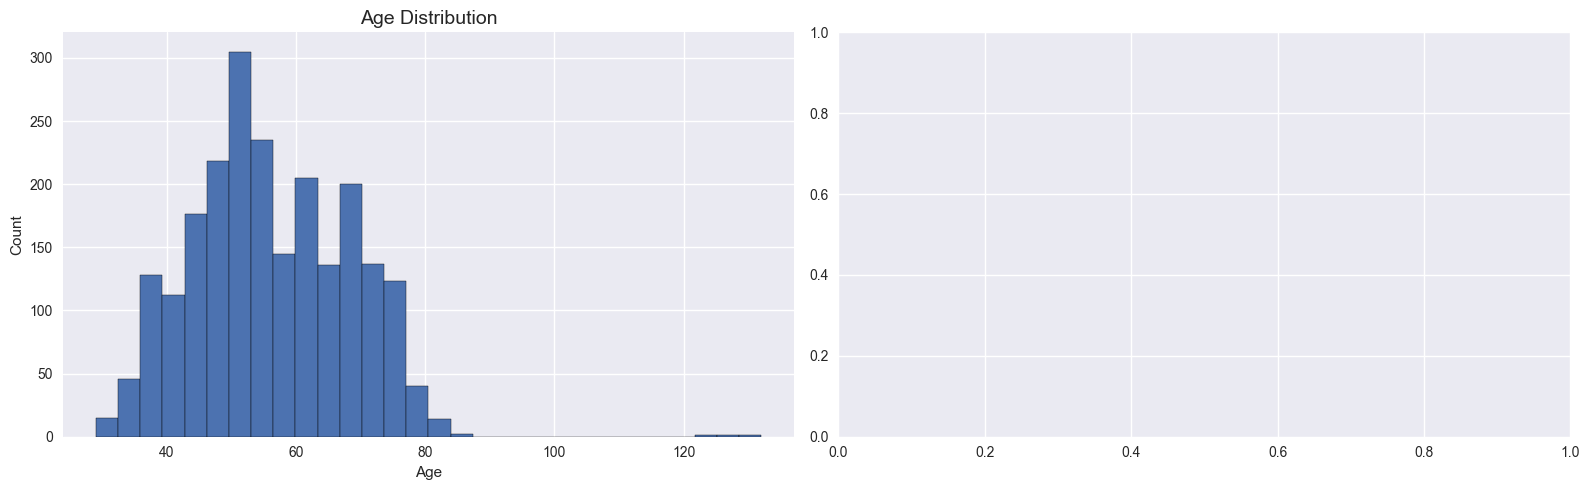

In [6]:
plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(1, 2, figsize=(16,5))

# Histogram
ax[0].hist(df['Age'], bins=30, edgecolor='black')
ax[0].set_title("Age Distribution", fontsize=14)
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Count")

plt.tight_layout()
plt.show()

**=> Có một vài giá trị khoảng từ 100 tuổi trở đi (giá trị ngoại lai). Nhóm loại bỏ để không gây noise cho việc huấn luyện. Chỉ giữ lại giá trị Age <= 100**

In [7]:
df = df[df['Age'] <= 100]

**2.5. Tạo cột Tổng chi tiêu (Total_Spend) = MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts + MntGoldProds**



In [8]:
money_cols = [c for c in df.columns if c.startswith('Mnt')]
if money_cols:
    df['Total_Spend'] = df[money_cols].sum(axis=1)

**2.6. Xử lý giá trị thiếu (Missing Values)**

In [9]:
# Check columns have missing values
df.isnull().sum()

Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
Tenure_days             0
Age                     0
Total_Spend             0
dtype: int64

**Cột Income có 24 giá trị null => Loại bỏ trước khi huấn luyện mô hình**

In [10]:
df['Income'] = df.groupby(['Education'])['Income'].transform(lambda x: x.fillna(x.median()))

**2.7. Gom nhóm và chuẩn hóa các biến phân loại (Categorical)**

In [11]:
# In ra các cột chứa biến phân loại
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['Education', 'Marital_Status'], dtype='object')


**Minh họa dữ liệu cột Marital_Status**

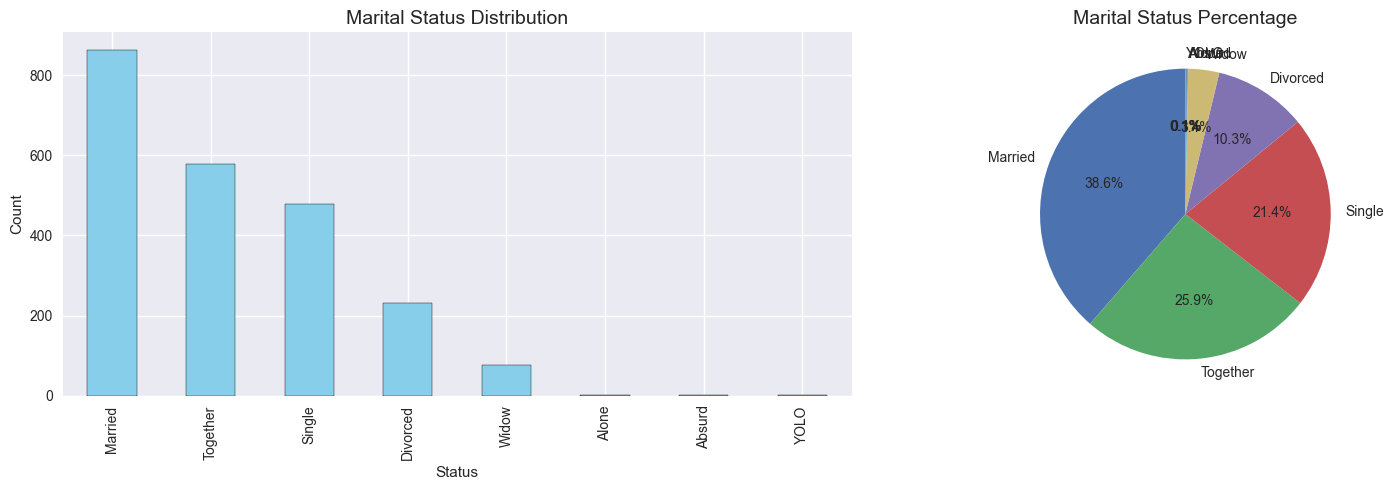

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))

# Barplot
df['Marital_Status'].value_counts().plot(kind='bar', ax=ax[0], color='skyblue', edgecolor='black')
ax[0].set_title("Marital Status Distribution", fontsize=14)
ax[0].set_xlabel("Status")
ax[0].set_ylabel("Count")

# Pie chart
df['Marital_Status'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=ax[1], startangle=90
)
ax[1].set_title("Marital Status Percentage", fontsize=14)
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Các biến phân loại 'Alone', 'Absurd', 'YOLO' có tần suất cực kỳ thấp so với các giá trị khác. Vì vậy, chúng ta cần gom nhóm 3 đặc trưng đó thành 1 đặc trưng chung là 'Other' để tránh dữ liệu ngoại lai.**

In [13]:
# Gom các tình trạng hôn nhân ít gặp (Absurd, YOLO, Alone) vào 'Other'
df['Marital_Status'] = df['Marital_Status'].replace(['Absurd', 'YOLO', 'Alone'], 'Other')

**Minh họa dữ liệu cột Education**

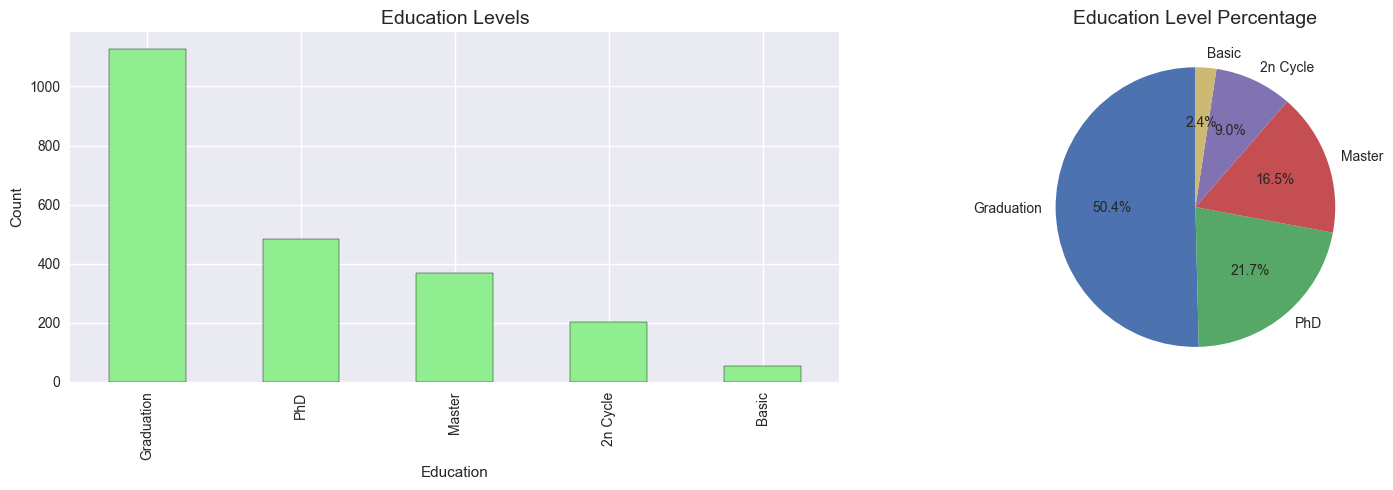

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))

# Barplot
df['Education'].value_counts().plot(kind='bar', ax=ax[0], color='lightgreen', edgecolor='black')
ax[0].set_title("Education Levels", fontsize=14)
ax[0].set_xlabel("Education")
ax[0].set_ylabel("Count")

# Pie chart
df['Education'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=ax[1], startangle=90
)
ax[1].set_title("Education Level Percentage", fontsize=14)
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

**2.8. Preprocessing pipeline (Encoder + Scaler)**

In [15]:
# Xác định cột số và cột phân loại
features = [c for c in df.columns if c not in ['Response', 'Education', 'Marital_Status']]
cat_cols = ['Education', 'Marital_Status']

X_raw = df.drop(columns=['Response'])
y = df['Response']

# Pipeline xử lý: Scale cho biến số và OneHot cho biến phân loại
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

# Fit và Transform
X_processed = preprocessor.fit_transform(X_raw)

print(f"Kích thước X sau khi Preprocessing: {X_processed.shape}")

Kích thước X sau khi Preprocessing: (2237, 30)


# PHẦN 3: KHỞI TẠO CÁC MÔ HÌNH

In [16]:
# Base Models

# 1. Random Forest
rf_model = RandomForestClassifier(n_estimators=200, criterion='entropy', max_depth=20, random_state=42)
# 2. XGBoost
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, use_label_encoder=False, eval_metric='logloss', random_state=42)
# 3. AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, learning_rate=0.8, random_state=42)
# 4. LightGBM
lgbm_model = LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=31, random_state=42, verbose=-1)

base_learners = [
    ('RF', rf_model),
    ('XGB', xgb_model),
    ('ADA', ada_model),
    ('LGBM', lgbm_model)
]

# HSLR (Hybrid Stacking Logistic Regression) = Base Learners (RF, XGB, ADA, LGBM) + Meta-Learner (Logistic Regression)
hslr_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)
all_models = base_learners + [('HSLR', hslr_model)]

In [17]:
# Hàm hiển thị kết quả từng model
def get_independent_test_table(models, X_train, y_train, X_test, y_test):
    results = []
    for name, model in models:
        # Train
        model.fit(X_train, y_train)
        # Predict
        y_pred = model.predict(X_test)
        try:
            y_prob = model.predict_proba(X_test)[:, 1]
            roc = roc_auc_score(y_test, y_prob)
        except:
            roc = 0.0
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        mcc = matthews_corrcoef(y_test, y_pred)

        results.append({
            "Classifier": name,
            "Accuracy": acc * 100,
            "Precision": prec * 100,
            "Recall": rec * 100,
            "MCC": mcc * 100,
            "F1": f1 * 100,
            "ROC": roc
        })
    df_res = pd.DataFrame(results)
    return df_res[["Classifier", "Accuracy", "Precision", "Recall", "MCC", "F1", "ROC"]].round(3)

# Hàm hiển thị bảng kết quả (K-Fold CV)
def get_cv_table(models, X, y, k=5):
    results = []
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scoring = {
        'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall',
        'f1': 'f1', 'mcc': make_scorer(matthews_corrcoef), 'roc_auc': 'roc_auc'
    }
    for name, model in models:
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        results.append({
            "Classifier": name,
            "Accuracy": scores['test_accuracy'].mean() * 100,
            "Precision": scores['test_precision'].mean() * 100,
            "Recall": scores['test_recall'].mean() * 100,
            "MCC": scores['test_mcc'].mean() * 100,
            "F1": scores['test_f1'].mean() * 100,
            "ROC": scores['test_roc_auc'].mean()
        })
    df_res = pd.DataFrame(results)
    return df_res[["Classifier", "Accuracy", "Precision", "Recall", "MCC", "F1", "ROC"]].round(3)

# **PHẦN 4: CÂN BẰNG DỮ LIỆU VỚI SMOTE VÀ BORDERLINE-SMOTE, CTGAN**

In [18]:
df['Response'].value_counts()

Response
0    1903
1     334
Name: count, dtype: int64

Imbalanced Target Distribution: `Response`

- **Negative (0): 1906 samples**
- **Positive (1): 334 samples**

→ Tỷ lệ: **85% vs 15%**  
→ Dữ liệu **mất cân bằng mạnh**, cần áp dụng:  
  - SMOTE  
  - Borderline-SMOTE  
  - CTGAN

## **4.1. SMOTE**

In [19]:
print("--- CÂN BẰNG DỮ LIỆU VỚI SMOTE ---")

# Khởi tạo SMOTE
smote = SMOTE(
    sampling_strategy='minority',
    k_neighbors=5,
    random_state=None
)

X_smote, y_smote = smote.fit_resample(X_processed, y)

print(f"Phân bố lớp sau SMOTE: {Counter(y_smote)}")

# Chia train/test cho tập SMOTE
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_smote, y_smote, test_size=0.3, random_state=42, stratify=y_smote
)
print(f"Tập dữ liệu SMOTE: Train {X_train_smote.shape}, Test {X_test_smote.shape}")

--- CÂN BẰNG DỮ LIỆU VỚI SMOTE ---
Phân bố lớp sau SMOTE: Counter({1: 1903, 0: 1903})
Tập dữ liệu SMOTE: Train (2664, 30), Test (1142, 30)


## **4.2. BORDERLINE-SMOTE**

In [20]:
print("--- CÂN BẰNG DỮ LIỆU VỚI BORDERLINE-SMOTE ---")

# Khởi tạo Borderline-SMOTE
bsmote = BorderlineSMOTE(random_state=42, kind='borderline-1')

X_blsmote, y_blsmote = bsmote.fit_resample(X_processed, y)

print(f"Phân bố lớp sau Borderline-SMOTE: {Counter(y_blsmote)}")

# Chia train/test cho tập Borderline-SMOTE
X_train_bsmote, X_test_bsmote, y_train_bsmote, y_test_bsmote = train_test_split(
    X_blsmote, y_blsmote, test_size=0.3, random_state=42, stratify=y_blsmote
)
print(f"Tập dữ liệu BL-SMOTE: Train {X_train_bsmote.shape}, Test {X_test_bsmote.shape}")

--- CÂN BẰNG DỮ LIỆU VỚI BORDERLINE-SMOTE ---
Phân bố lớp sau Borderline-SMOTE: Counter({1: 1903, 0: 1903})
Tập dữ liệu BL-SMOTE: Train (2664, 30), Test (1142, 30)


## **4.3. CTGAN**

### **4.3.1. Tách dữ liệu theo lớp**

In [21]:
minority_data = df[df['Response'] == 1].copy()
majority_data = df[df['Response'] == 0].copy()

print(f"Số lượng mẫu lớp thiểu số (Response=1): {len(minority_data)}")
print(f"Số lượng mẫu lớp đa số (Response=0): {len(majority_data)}")

Số lượng mẫu lớp thiểu số (Response=1): 334
Số lượng mẫu lớp đa số (Response=0): 1903


In [22]:
df['Kidhome'].value_counts()

Kidhome
0    1291
1     898
2      48
Name: count, dtype: int64

### **4.3.2. Xác định các biến rời rạc và liên tục cho CTGAN**

In [23]:
# Các cột phân loại đã được xác định trước đó
discrete_columns_ctgan = list(cat_cols)

# Thêm các cột số nhưng có tính chất rời rạc
discrete_numerical_cols = [
    'Kidhome', 'Teenhome', 'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain'
]

discrete_columns_ctgan.extend(discrete_numerical_cols)

# Xác định các cột liên tục (những cột còn lại không phải là rời rạc và không phải biến mục tiêu)
all_columns = df.drop(columns=['Response']).columns.tolist()
continuous_columns_ctgan = [col for col in all_columns if col not in discrete_columns_ctgan]

print("Các cột rời rạc cho CTGAN:")
print(discrete_columns_ctgan)
print("\nCác cột liên tục cho CTGAN:")
print(continuous_columns_ctgan)

Các cột rời rạc cho CTGAN:
['Education', 'Marital_Status', 'Kidhome', 'Teenhome', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain']

Các cột liên tục cho CTGAN:
['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'Tenure_days', 'Age', 'Total_Spend']


### **4.3.3. Huấn luyện CTGAN trên lớp thiểu số**

In [24]:
from ctgan import CTGAN

In [25]:
print("\n--- BẮT ĐẦU HUẤN LUYỆN CTGAN ---")
ctgan_model = CTGAN(epochs=300,
                    batch_size=500,
                    generator_dim=(256,256),
                    embedding_dim=128,
                    verbose=True)
ctgan_model.fit(minority_data, discrete_columns_ctgan)
print("Huấn luyện CTGAN hoàn tất!")


--- BẮT ĐẦU HUẤN LUYỆN CTGAN ---


Gen. (+00.27) | Discrim. (-00.02): 100%|██████████| 300/300 [00:15<00:00, 19.95it/s]

Huấn luyện CTGAN hoàn tất!


### **4.3.4. Sinh dữ liệu tổng hợp (Synthetic Data)**

In [26]:
n_to_generate = len(majority_data) - len(minority_data)

if n_to_generate > 0:
    print(f"Đang sinh thêm {n_to_generate} mẫu dữ liệu tổng hợp...")
    synthetic_data = ctgan_model.sample(n_to_generate)

    # Xử lý hậu kỳ: Làm tròn các cột số nguyên bị sinh ra dưới dạng số thực
    int_columns = ['Kidhome', 'Teenhome', 'NumWebVisitsMonth', 'Age', 'Recency',
                   'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
    for col in int_columns:
        if col in synthetic_data.columns:
            synthetic_data[col] = synthetic_data[col].round().astype(int)

    # Gộp dữ liệu: Gốc (Đa số) + Gốc (Thiểu số) + Tổng hợp (Thiểu số)
    balanced_df = pd.concat([majority_data, minority_data, synthetic_data], ignore_index=True)


    balanced_df['Response'] = balanced_df['Response'].round().astype(int)

    print("\nPhân bổ lớp sau khi cân bằng:")
    print(balanced_df['Response'].value_counts())
else:
    print("Dữ liệu đã cân bằng, không cần sinh thêm.")
    balanced_df = df.copy()

Đang sinh thêm 1569 mẫu dữ liệu tổng hợp...

Phân bổ lớp sau khi cân bằng:
Response
0    1903
1    1903
Name: count, dtype: int64


In [27]:
categorical_cols_for_encoding = balanced_df.select_dtypes(include=['object']).columns
balanced_df_encoded = pd.get_dummies(balanced_df, columns=categorical_cols_for_encoding, drop_first=True)


X_ctgan = balanced_df_encoded.drop('Response', axis=1)
y_ctgan = balanced_df_encoded['Response']


# Chia train/test
X_train_ctgan, X_test_ctgan, y_train_ctgan, y_test_ctgan = train_test_split(
                                                              X_ctgan, y_ctgan, test_size=0.3)

# **PHẦN 5: KẾT QUẢ ĐÁNH GIÁ (EVALUATION METRICS) CÁC MÔ HÌNH ENSEMBLE**

## **5.1. Kết quả với SMOTE**

In [28]:
print("\n" + "="*60)
print("=== RESULTS FOR SMOTE DATA ===")
print("="*60)

# Independent Test
print("\n--- INDEPENDENT SET TESTING RESULTS (SMOTE) ---")
df_indep_smote = get_independent_test_table(all_models, X_train_smote, y_train_smote, X_test_smote, y_test_smote)
display(df_indep_smote)

# 5-Fold CV
print("\n--- RESULTS FOR SMOTE DATA USING 5-FOLD CV ---")
df_cv5_smote = get_cv_table(all_models, X_train_smote, y_train_smote, k=5)
display(df_cv5_smote)

# 10-Fold CV
print("\n--- RESULTS FOR SMOTE DATA USING 10-FOLD CV ---")
df_cv10_smote = get_cv_table(all_models, X_train_smote, y_train_smote, k=10)
display(df_cv10_smote)


=== RESULTS FOR SMOTE DATA ===

--- INDEPENDENT SET TESTING RESULTS (SMOTE) ---


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC
0,RF,94.221,93.610,94.921,88.450,94.261,0.983
1,XGB,94.396,93.186,95.797,88.826,94.473,0.985
2,ADA,88.179,86.700,90.193,76.419,88.412,0.955
3,LGBM,94.221,92.869,95.797,88.485,94.310,0.986
4,HSLR,94.658,94.118,95.271,89.324,94.691,0.985



--- RESULTS FOR SMOTE DATA USING 5-FOLD CV ---


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC
0,RF,93.469,92.576,94.517,86.970,93.531,0.982
1,XGB,93.056,91.771,94.593,86.159,93.157,0.982
2,ADA,87.013,85.893,88.663,74.087,87.243,0.948
3,LGBM,93.131,92.525,93.842,86.283,93.173,0.982
4,HSLR,93.544,93.225,93.917,87.107,93.561,0.983



--- RESULTS FOR SMOTE DATA USING 10-FOLD CV ---


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC
0,RF,94.068,93.352,94.969,88.207,94.123,0.984
1,XGB,92.754,92.152,93.542,85.575,92.812,0.983
2,ADA,87.386,86.273,89.041,74.843,87.616,0.951
3,LGBM,93.091,92.800,93.466,86.211,93.118,0.983
4,HSLR,93.955,93.887,94.067,87.948,93.956,0.984


## **5.2. Kết quả với Borderline-SMOTE**

In [29]:
print("\n\n" + "="*60)
print("=== RESULTS FOR BORDERLINE-SMOTE DATA ===")
print("="*60)

# Independent Test
print("\n--- INDEPENDENT SET TESTING RESULTS (BORDERLINE-SMOTE) ---")
df_indep_bsmote = get_independent_test_table(all_models, X_train_bsmote, y_train_bsmote, X_test_bsmote, y_test_bsmote)
display(df_indep_bsmote)

# 5-Fold CV
print("\n--- RESULTS FOR BORDERLINE-SMOTE DATA USING 5-FOLD CV ---")
df_cv5_bsmote = get_cv_table(all_models, X_blsmote, y_blsmote, k=5)
display(df_cv5_bsmote)

# 10-Fold CV (MỚI THÊM)
print("\n--- RESULTS FOR BORDERLINE-SMOTE DATA USING 10-FOLD CV ---")
df_cv10_bsmote = get_cv_table(all_models, X_blsmote, y_blsmote, k=10)
display(df_cv10_bsmote)



=== RESULTS FOR BORDERLINE-SMOTE DATA ===

--- INDEPENDENT SET TESTING RESULTS (BORDERLINE-SMOTE) ---


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC
0,RF,95.096,93.570,96.848,90.248,95.181,0.984
1,XGB,94.133,93.299,95.096,88.283,94.189,0.984
2,ADA,86.953,85.884,88.441,73.938,87.144,0.951
3,LGBM,94.133,93.750,94.571,88.270,94.159,0.987
4,HSLR,94.658,93.966,95.447,89.328,94.700,0.985



--- RESULTS FOR BORDERLINE-SMOTE DATA USING 5-FOLD CV ---


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC
0,RF,94.693,94.031,95.481,89.425,94.736,0.986
1,XGB,93.904,93.558,94.324,87.839,93.925,0.985
2,ADA,87.572,86.899,88.543,75.206,87.687,0.950
3,LGBM,93.773,93.706,93.903,87.591,93.780,0.985
4,HSLR,94.719,94.453,95.060,89.480,94.735,0.986



--- RESULTS FOR BORDERLINE-SMOTE DATA USING 10-FOLD CV ---


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC
0,RF,94.955,94.484,95.535,89.951,94.989,0.986
1,XGB,93.510,93.174,93.957,87.085,93.531,0.986
2,ADA,87.519,86.831,88.490,75.074,87.641,0.951
3,LGBM,93.984,93.986,94.010,88.014,93.973,0.985
4,HSLR,94.902,94.843,95.008,89.841,94.907,0.987


## **5.3. Kết quả với CTGAN**

In [30]:
print("\n\n" + "="*60)
print("=== RESULTS FOR CTGAN DATA ===")
print("="*60)

# Independent Test
print("\n--- INDEPENDENT SET TESTING RESULTS (CTGAN) ---")
df_indep_ctgan = get_independent_test_table(
    all_models, 
    X_train_ctgan.to_numpy(), 
    y_train_ctgan.to_numpy(), 
    X_test_ctgan.to_numpy(), 
    y_test_ctgan.to_numpy()
)
display(df_indep_ctgan)

# 5-Fold CV
print("\n--- RESULTS FOR CTGAN DATA USING 5-FOLD CV ---")
df_cv5_ctgan = get_cv_table(
    all_models, 
    X_train_ctgan.to_numpy(), 
    y_train_ctgan.to_numpy(), 
    k=5
)
display(df_cv5_ctgan)

# 10-Fold CV 
print("\n--- RESULTS FOR CTGAN DATA USING 10-FOLD CV ---")
df_cv10_ctgan = get_cv_table(
    all_models, 
    X_train_ctgan.to_numpy(), 
    y_train_ctgan.to_numpy(), 
    k=10
)
display(df_cv10_ctgan)



=== RESULTS FOR CTGAN DATA ===

--- INDEPENDENT SET TESTING RESULTS (CTGAN) ---


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC
0,RF,90.981,92.505,89.085,82.013,90.762,0.968
1,XGB,91.419,92.883,89.613,82.884,91.219,0.971
2,ADA,87.391,91.732,82.042,75.183,86.617,0.942
3,LGBM,91.156,92.844,89.085,82.374,90.925,0.970
4,HSLR,91.506,92.280,90.493,83.025,91.378,0.970



--- RESULTS FOR CTGAN DATA USING 5-FOLD CV ---


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC
0,RF,90.990,93.839,87.790,82.164,90.707,0.972
1,XGB,90.915,93.347,88.165,81.986,90.665,0.970
2,ADA,86.861,91.484,81.423,74.251,86.102,0.944
3,LGBM,91.441,93.987,88.614,83.047,91.203,0.971
4,HSLR,91.366,93.349,89.139,82.836,91.185,0.972



--- RESULTS FOR CTGAN DATA USING 10-FOLD CV ---


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC
0,RF,91.441,94.286,88.315,83.085,91.180,0.973
1,XGB,91.592,94.010,88.914,83.331,91.376,0.975
2,ADA,87.085,91.991,81.418,74.743,86.327,0.946
3,LGBM,91.779,94.296,88.987,83.712,91.551,0.975
4,HSLR,91.929,94.020,89.662,83.994,91.761,0.975


# **PHẦN 6: TỔNG HỢP KẾT QUẢ**

## **6.1. Kết quả với SMOTE**


=== TỔNG HỢP KẾT QUẢ CHO DỮ LIỆU SMOTE ===

Bảng so sánh độ chính xác (Accuracy - SMOTE):
  Model  70/30 Split  5-Fold CV  10-Fold CV
0    RF       94.221     93.469      94.068
4  HSLR       94.658     93.544      93.955
3  LGBM       94.221     93.131      93.091
1   XGB       94.396     93.056      92.754
2   ADA       88.179     87.013      87.386


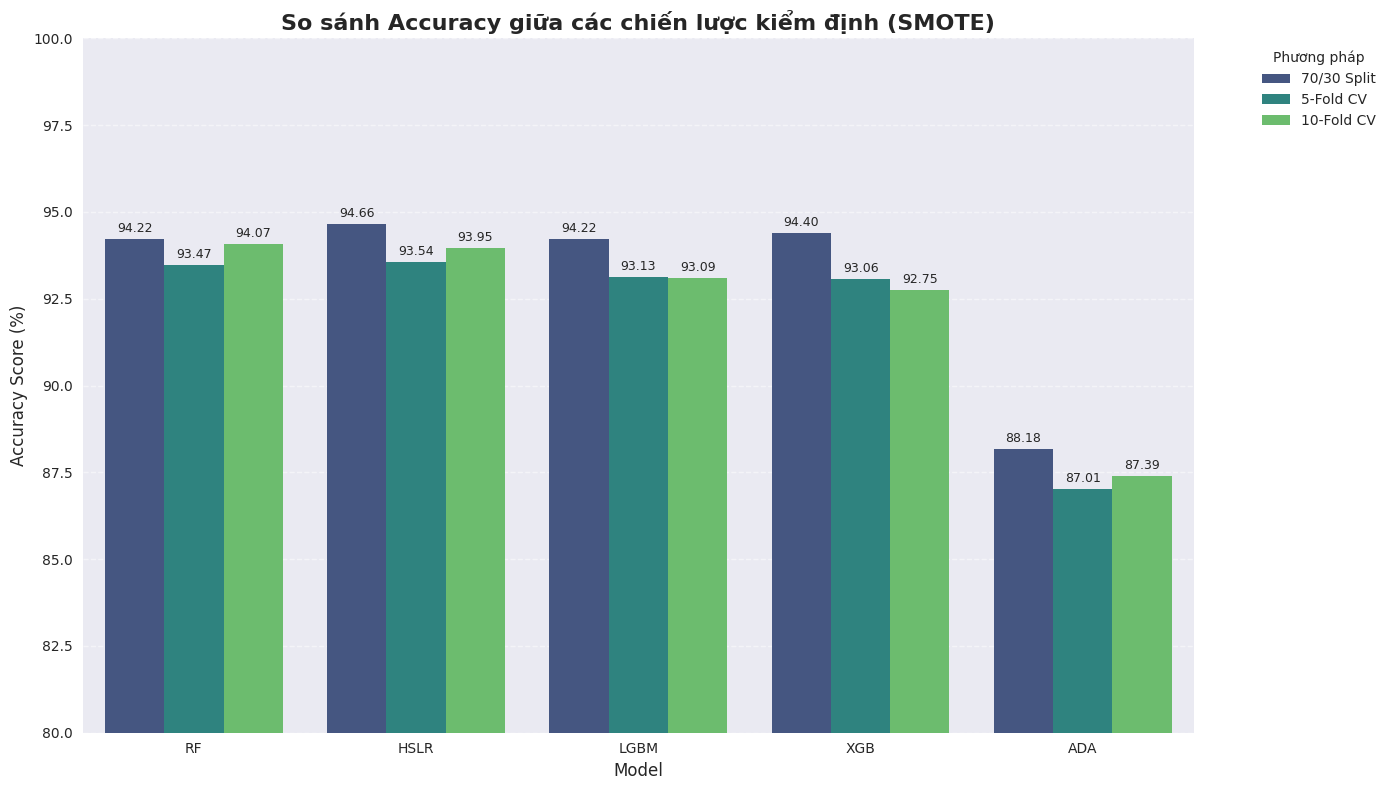

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n" + "="*60)
print("=== TỔNG HỢP KẾT QUẢ CHO DỮ LIỆU SMOTE ===")
print("="*60)

s_split_smote = df_indep_smote.set_index("Classifier")["Accuracy"]
s_cv5_smote = df_cv5_smote.set_index("Classifier")["Accuracy"]
s_cv10_smote = df_cv10_smote.set_index("Classifier")["Accuracy"]

summary_df_smote = pd.DataFrame({
    "70/30 Split": s_split_smote,
    "5-Fold CV": s_cv5_smote,
    "10-Fold CV": s_cv10_smote
})

summary_df_smote.index.name = "Model"
summary_df_smote = summary_df_smote.reset_index()

summary_df_smote = summary_df_smote.sort_values(by="10-Fold CV", ascending=False)

print("\nBảng so sánh độ chính xác (Accuracy - SMOTE):")
print(summary_df_smote.to_string())

plt.figure(figsize=(14, 8))

summary_long_smote = summary_df_smote.melt(id_vars="Model", var_name="Evaluation Method", value_name="Accuracy")

ax = sns.barplot(
    data=summary_long_smote,
    x="Model",
    y="Accuracy",
    hue="Evaluation Method",
    palette="viridis"
)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] # Explicitly set sans-serif font
plt.rcParams['axes.unicode_minus'] = False # Handle unicode minus sign
plt.title("So sánh Accuracy giữa các chiến lược kiểm định (SMOTE)", fontsize=16, fontweight='bold')
plt.ylim(80, 100)
plt.ylabel("Accuracy Score (%)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.legend(title="Phương pháp", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## **6.2. Kết quả với Borderline-SMOTE**


=== TỔNG HỢP KẾT QUẢ CHO DỮ LIỆU BORDERLINE-SMOTE ===

Bảng so sánh độ chính xác (Accuracy - Borderline-SMOTE):
  Model  70/30 Split  5-Fold CV  10-Fold CV
0    RF       95.096     94.693      94.955
4  HSLR       94.658     94.719      94.902
3  LGBM       94.133     93.773      93.984
1   XGB       94.133     93.904      93.510
2   ADA       86.953     87.572      87.519


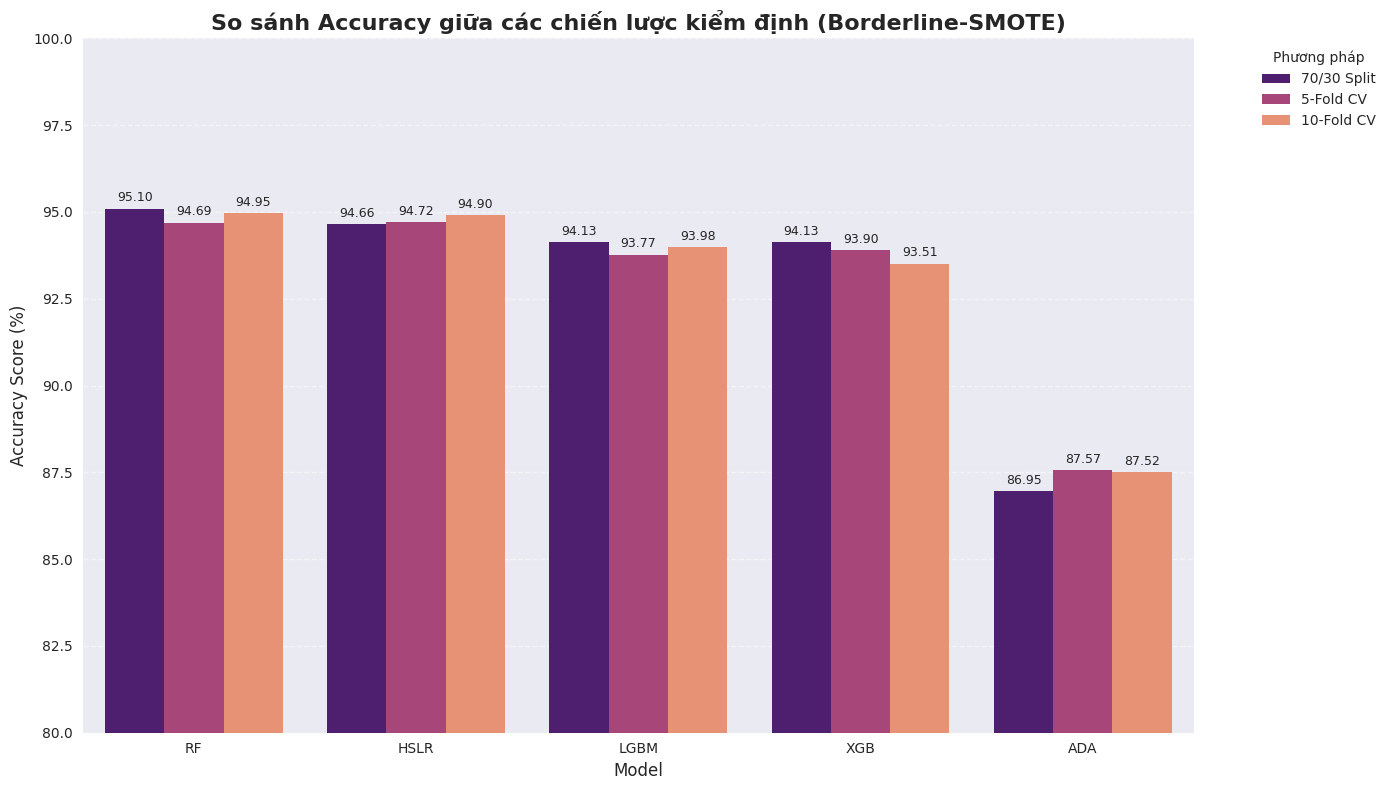

In [32]:
print("\n" + "="*60)
print("=== TỔNG HỢP KẾT QUẢ CHO DỮ LIỆU BORDERLINE-SMOTE ===")
print("="*60)

s_split_bsmote = df_indep_bsmote.set_index("Classifier")["Accuracy"]
s_cv5_bsmote = df_cv5_bsmote.set_index("Classifier")["Accuracy"]
s_cv10_bsmote = df_cv10_bsmote.set_index("Classifier")["Accuracy"]

summary_df_bsmote = pd.DataFrame({
    "70/30 Split": s_split_bsmote,
    "5-Fold CV": s_cv5_bsmote,
    "10-Fold CV": s_cv10_bsmote
})

summary_df_bsmote.index.name = "Model"
summary_df_bsmote = summary_df_bsmote.reset_index()

summary_df_bsmote = summary_df_bsmote.sort_values(by="10-Fold CV", ascending=False)

print("\nBảng so sánh độ chính xác (Accuracy - Borderline-SMOTE):")
print(summary_df_bsmote.to_string())

plt.figure(figsize=(14, 8))

summary_long_bsmote = summary_df_bsmote.melt(id_vars="Model", var_name="Evaluation Method", value_name="Accuracy")

ax = sns.barplot(
    data=summary_long_bsmote,
    x="Model",
    y="Accuracy",
    hue="Evaluation Method",
    palette="magma"
)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title("So sánh Accuracy giữa các chiến lược kiểm định (Borderline-SMOTE)", fontsize=16, fontweight='bold')
plt.ylim(80, 100)
plt.ylabel("Accuracy Score (%)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.legend(title="Phương pháp", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## **6.3. Kết quả với CTGAN**


=== TỔNG HỢP KẾT QUẢ CHO DỮ LIỆU CTGAN ===

Bảng so sánh độ chính xác (Accuracy - CTGAN):
  Model  70/30 Split  5-Fold CV  10-Fold CV
4  HSLR       91.506     91.366      91.929
3  LGBM       91.156     91.441      91.779
1   XGB       91.419     90.915      91.592
0    RF       90.981     90.990      91.441
2   ADA       87.391     86.861      87.085


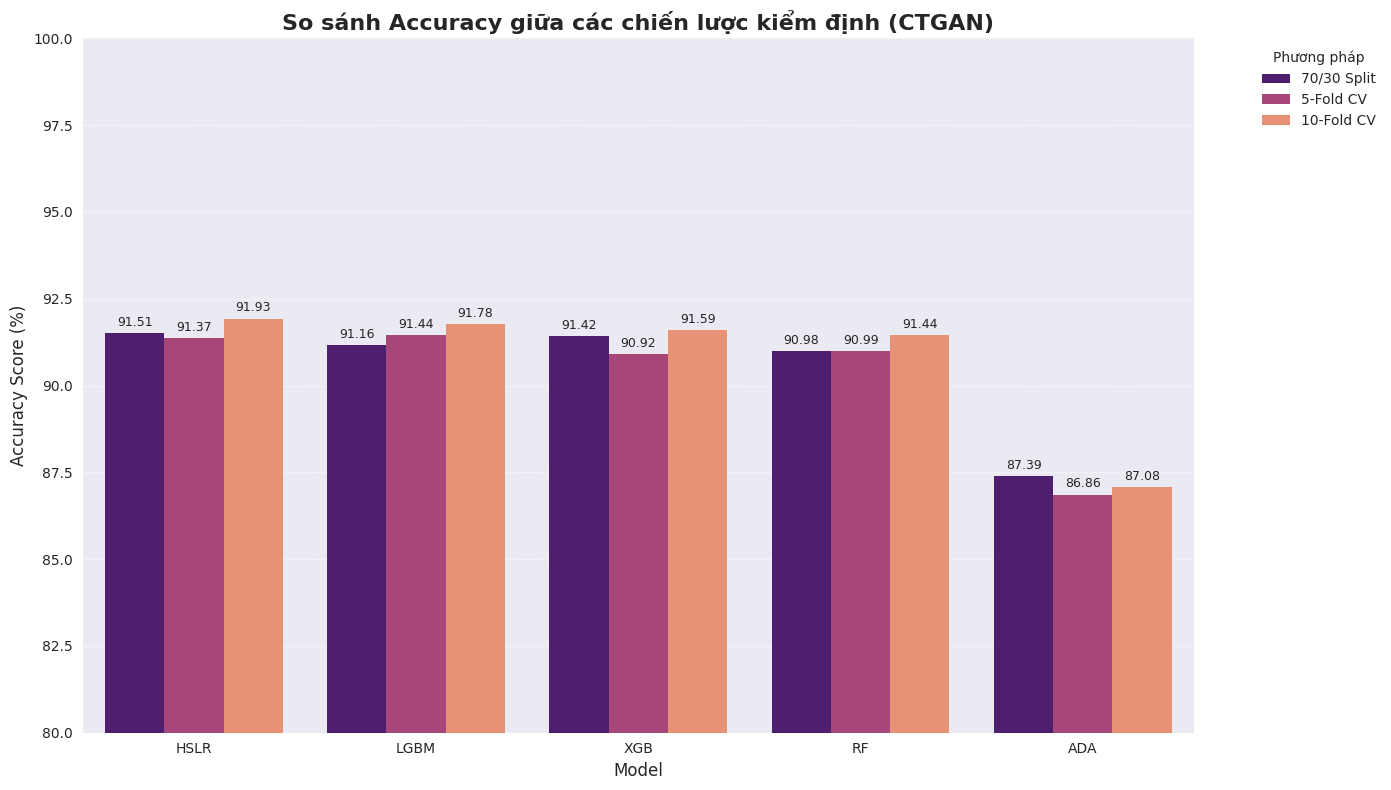

In [33]:
print("\n" + "="*60)
print("=== TỔNG HỢP KẾT QUẢ CHO DỮ LIỆU CTGAN ===")
print("="*60)

s_split_ctgan = df_indep_ctgan.set_index("Classifier")["Accuracy"]
s_cv5_ctgan = df_cv5_ctgan.set_index("Classifier")["Accuracy"]
s_cv10_ctgan = df_cv10_ctgan.set_index("Classifier")["Accuracy"]

summary_df_ctgan = pd.DataFrame({
    "70/30 Split": s_split_ctgan,
    "5-Fold CV": s_cv5_ctgan,
    "10-Fold CV": s_cv10_ctgan
})

summary_df_ctgan.index.name = "Model"
summary_df_ctgan = summary_df_ctgan.reset_index()

summary_df_ctgan = summary_df_ctgan.sort_values(by="10-Fold CV", ascending=False)

print("\nBảng so sánh độ chính xác (Accuracy - CTGAN):")
print(summary_df_ctgan.to_string())

plt.figure(figsize=(14, 8))

summary_long_ctgan = summary_df_ctgan.melt(id_vars="Model", var_name="Evaluation Method", value_name="Accuracy")

ax = sns.barplot(
    data=summary_long_ctgan,
    x="Model",
    y="Accuracy",
    hue="Evaluation Method",
    palette="magma"
)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title("So sánh Accuracy giữa các chiến lược kiểm định (CTGAN)", fontsize=16, fontweight='bold')
plt.ylim(80, 100)
plt.ylabel("Accuracy Score (%)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.legend(title="Phương pháp", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

# **PHẦN 7: KẾT LUẬN**

In [34]:
df_cv10_smote['Method'] = 'SMOTE'
df_cv10_bsmote['Method'] = 'Borderline-SMOTE'
df_cv10_ctgan['Method'] = 'CTGAN'

combined_results_df = pd.concat([
    df_cv10_smote,
    df_cv10_bsmote,
    df_cv10_ctgan
], ignore_index=True)

print("Combined Results DataFrame (10-Fold CV):")
display(combined_results_df)

Combined Results DataFrame (10-Fold CV):


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC,Method
0,RF,94.068,93.352,94.969,88.207,94.123,0.984,SMOTE
1,XGB,92.754,92.152,93.542,85.575,92.812,0.983,SMOTE
2,ADA,87.386,86.273,89.041,74.843,87.616,0.951,SMOTE
3,LGBM,93.091,92.800,93.466,86.211,93.118,0.983,SMOTE
4,HSLR,93.955,93.887,94.067,87.948,93.956,0.984,SMOTE
5,RF,94.955,94.484,95.535,89.951,94.989,0.986,Borderline-SMOTE
6,XGB,93.510,93.174,93.957,87.085,93.531,0.986,Borderline-SMOTE
7,ADA,87.519,86.831,88.490,75.074,87.641,0.951,Borderline-SMOTE
8,LGBM,93.984,93.986,94.010,88.014,93.973,0.985,Borderline-SMOTE
9,HSLR,94.902,94.843,95.008,89.841,94.907,0.987,Borderline-SMOTE


In [35]:
print("Bảng tổng hợp các chỉ số 10-Fold CV (Combined):")
display(combined_results_df)

Bảng tổng hợp các chỉ số 10-Fold CV (Combined):


,Classifier,Accuracy,Precision,Recall,MCC,F1,ROC,Method
0,RF,94.068,93.352,94.969,88.207,94.123,0.984,SMOTE
1,XGB,92.754,92.152,93.542,85.575,92.812,0.983,SMOTE
2,ADA,87.386,86.273,89.041,74.843,87.616,0.951,SMOTE
3,LGBM,93.091,92.800,93.466,86.211,93.118,0.983,SMOTE
4,HSLR,93.955,93.887,94.067,87.948,93.956,0.984,SMOTE
5,RF,94.955,94.484,95.535,89.951,94.989,0.986,Borderline-SMOTE
6,XGB,93.510,93.174,93.957,87.085,93.531,0.986,Borderline-SMOTE
7,ADA,87.519,86.831,88.490,75.074,87.641,0.951,Borderline-SMOTE
8,LGBM,93.984,93.986,94.010,88.014,93.973,0.985,Borderline-SMOTE
9,HSLR,94.902,94.843,95.008,89.841,94.907,0.987,Borderline-SMOTE


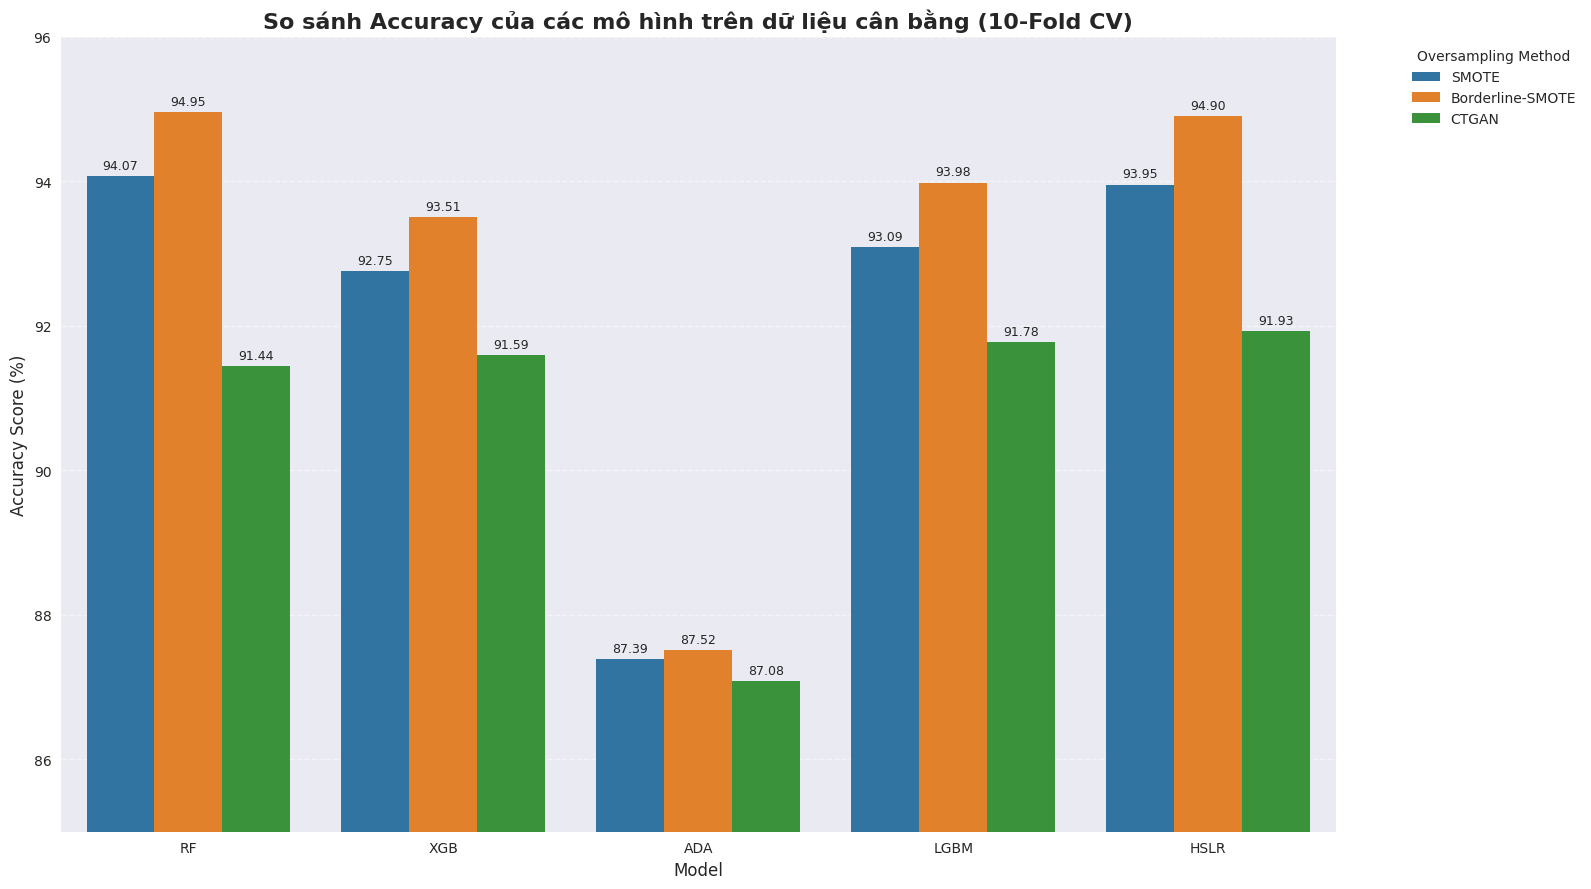

In [36]:
plt.figure(figsize=(16, 9))

ax = sns.barplot(
    data=combined_results_df,
    x="Classifier",
    y="Accuracy",
    hue="Method",
    palette="tab10" # Choose a distinct palette
)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title("So sánh Accuracy của các mô hình trên dữ liệu cân bằng (10-Fold CV)", fontsize=16, fontweight='bold')
plt.ylim(85, 96) # Adjust y-limit to better visualize differences
plt.ylabel("Accuracy Score (%)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.legend(title="Oversampling Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

### Nhận xét
Dựa trên bảng và biểu đồ so sánh, phương pháp cân bằng dữ liệu **Borderline-SMOTE** mang lại hiệu suất tốt nhất cho các mô hình đã xây dựng, thể hiện qua các chỉ số Accuracy cao hơn so với SMOTE và CTGAN.

*   Ví dụ, mô hình HSLR đạt độ chính xác cao nhất với Borderline-SMOTE là 94.90%, tiếp theo là SMOTE với 93.99% và CTGAN với 92.34%.
*   CTGAN nói chung cho thấy hiệu suất thấp nhất về độ chính xác so với SMOTE và Borderline-SMOTE trên các mô hình đã đánh giá.

###
*   Nên ưu tiên sử dụng phương pháp cân bằng dữ liệu Borderline-SMOTE khi xây dựng các mô hình dự đoán trên tập dữ liệu này để tối ưu hóa hiệu suất.
*   Cần xem xét sâu hơn các chỉ số khác như Precision, Recall, F1-score và ROC AUC từ các mô hình được cân bằng bởi Borderline-SMOTE để hiểu rõ hơn về khả năng phân loại tổng thể, đặc biệt là trong việc xử lý các trường hợp dương tính giả và âm tính giả.
